In [ ]:
"""
Quarter_Geom.py

PINN for Steady-State Heat Equation on Quarter Annulus
======================================================
Comparable implementation to Full_Geom.py for performance comparison.

Domain: First quadrant (x >= 0, y >= 0), R1 <= r <= R2
PDE: nabla^2 T = 0 (Laplace equation)
BCs:
  - Inner arc (r = R1): T = T_cold (Dirichlet)
  - Outer arc (r = R2): T = T_hot (Dirichlet)
  - x = 0 boundary: dT/dx = 0 (Neumann/Symmetry)
  - y = 0 boundary: dT/dy = 0 (Neumann/Symmetry)

Training Strategy:
  1. Adam optimizer with cosine annealing LR schedule
  2. L-BFGS optimizer for fine-tuning

Key design choices (matching full geometry code):
  - LHS sampling for interior points
  - nn.Sequential network construction
  - Minibatching during Adam phase
  - Same architecture, iterations, and loss weighting structure
  - 1/4 proportional boundary points (since domain is 1/4 the area)
  - NORMALIZED loss residuals for proper gradient balancing

Normalization scheme (consistent with Full_Geom.py):
  - Inputs:       x_norm = x / L_char,  y_norm = y / L_char
  - Output:       u = T_mean + (T_range/2) * network_output
  - PDE loss:     laplacian / (T_range / L_char^2)
  - Dirichlet BC: (T - T_target) / T_range
  - Neumann BC:   (dT/dn) / (T_range / L_char)
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time
from typing import Tuple


# =============================================================================
# CONFIGURATION
# =============================================================================

In [ ]:
class Config:
    """Configuration container for quarter annulus problem."""

    def __init__(
        self,
        R1: float = 1.0,
        R2: float = 3.0,
        T_cold: float = 100.0,
        T_hot: float = 500.0,
        hidden_layers: int = 4,
        neurons_per_layer: int = 32,
        adam_iterations: int = 10000,
        lbfgs_iterations: int = 3000,
        adam_lr: float = 1e-3,
        lambda_pde: float = 1.0,
        lambda_bc: float = 10.0,
        # Quarter geometry: 1/4 of full geometry points (proportional to area)
        n_interior: int = 500,           # 2000/4 = 500
        n_boundary_inner: int = 75,      # 300/4 = 75
        n_boundary_outer: int = 75,      # 300/4 = 75
        n_symmetry: int = 50,            # Points on each symmetry boundary (x=0 and y=0)
        batch_size: int = 128,           # 512/4 = 128 (proportional)
        resample_every: int = 100,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        # Geometry
        self.R1 = R1
        self.R2 = R2

        # Boundary conditions
        self.T_cold = T_cold
        self.T_hot = T_hot

        # Network architecture
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer

        # Training parameters
        self.adam_iterations = adam_iterations
        self.lbfgs_iterations = lbfgs_iterations
        self.adam_lr = adam_lr

        # Loss weights
        self.lambda_pde = lambda_pde
        self.lambda_bc = lambda_bc

        # Sampling points
        self.n_interior = n_interior
        self.n_boundary_inner = n_boundary_inner
        self.n_boundary_outer = n_boundary_outer
        self.n_symmetry = n_symmetry

        # Training settings
        self.batch_size = batch_size
        self.resample_every = resample_every
        self.device = device

        # Derived normalization quantities (matches Full_Geom.py)
        self.T_range = T_hot - T_cold
        self.T_mean = (T_hot + T_cold) / 2.0
        self.L_char = R2  # Characteristic length (same as full geometry)

    def __repr__(self):
        return f"""
Configuration (Quarter Annulus):
--------------------------------
Geometry: R1={self.R1}, R2={self.R2}
BCs: T_cold={self.T_cold}, T_hot={self.T_hot}
Network: {self.hidden_layers} layers x {self.neurons_per_layer} neurons
Training: Adam({self.adam_iterations}) -> L-BFGS({self.lbfgs_iterations})
Weights: lambda_pde={self.lambda_pde}, lambda_bc={self.lambda_bc}
Points: interior={self.n_interior}, inner={self.n_boundary_inner}, outer={self.n_boundary_outer}, symmetry={self.n_symmetry}x2
Device: {self.device}
"""


# =============================================================================
# NEURAL NETWORK
# =============================================================================

In [ ]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for quarter annulus.

    Architecture matches full geometry code:
    - nn.Sequential construction
    - Input normalization by L_char (quarter domain: x,y in [0,1] after scaling)
    - Output scaling: T = T_mean + (T_range/2) * network_output

    Note on input range: quarter domain maps x,y in [0, R2] -> [0, 1] after
    dividing by L_char, whereas full geometry maps [-R2, R2] -> [-1, 1].
    This difference is inherent to the geometry and physically correct.
    """

    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        # Build network
        layers = []

        # Input layer
        layers.append(nn.Linear(2, config.neurons_per_layer))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(config.hidden_layers - 1):
            layers.append(nn.Linear(config.neurons_per_layer, config.neurons_per_layer))
            layers.append(nn.Tanh())

        # Output layer
        layers.append(nn.Linear(config.neurons_per_layer, 1))

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights for good starting point."""
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

        # Initialize last layer to output near T_mean
        last_linear = list(self.network.children())[-1]
        nn.init.zeros_(last_linear.weight)
        last_linear.bias.data.fill_(0.0)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Forward pass with input normalization and output scaling."""
        if x.dim() == 1:
            x = x.unsqueeze(1)
        if y.dim() == 1:
            y = y.unsqueeze(1)

        # Normalize inputs by characteristic length (matches Full_Geom.py)
        x_norm = x / self.config.L_char
        y_norm = y / self.config.L_char

        inputs = torch.cat([x_norm, y_norm], dim=1)

        # Network output (approximately in [-1, 1] due to tanh)
        u_normalized = self.network(inputs)

        # Scale to physical temperature range (matches Full_Geom.py)
        u = self.config.T_mean + (self.config.T_range / 2.0) * u_normalized

        return u


# =============================================================================
# SAMPLER
# =============================================================================

In [ ]:
class Sampler:
    """Sampling utilities for quarter annular domain using LHS."""

    def __init__(self, config: Config):
        self.config = config
        self.device = config.device

    def sample_interior_lhs(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sample interior points using Latin Hypercube Sampling.
        Maps uniform samples to quarter annulus (theta in [0, pi/2]).
        """
        sampler = qmc.LatinHypercube(d=2, seed=None)
        samples = sampler.random(n=n_points)

        # Map to annular coordinates with uniform area distribution
        r_squared = self.config.R1**2 + samples[:, 0] * (self.config.R2**2 - self.config.R1**2)
        r = np.sqrt(r_squared)
        theta = samples[:, 1] * (np.pi / 2)  # Quarter annulus: theta in [0, pi/2]

        x = r * np.cos(theta)
        y = r * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_inner(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on inner arc (r = R1) for theta in [0, pi/2]."""
        theta = np.linspace(0, np.pi/2, n_points, endpoint=False)
        theta += np.random.uniform(0, (np.pi/2)/n_points, n_points)  # Jitter

        x = self.config.R1 * np.cos(theta)
        y = self.config.R1 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_outer(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on outer arc (r = R2) for theta in [0, pi/2]."""
        theta = np.linspace(0, np.pi/2, n_points, endpoint=False)
        theta += np.random.uniform(0, (np.pi/2)/n_points, n_points)  # Jitter

        x = self.config.R2 * np.cos(theta)
        y = self.config.R2 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_symmetry_x0(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sample points on x=0 boundary (y-axis) for Neumann BC: dT/dx = 0.
        Points along y in [R1, R2] with x = 0.
        """
        sampler = qmc.LatinHypercube(d=1, seed=None)
        samples = sampler.random(n=n_points).flatten()

        y = self.config.R1 + samples * (self.config.R2 - self.config.R1)
        x = np.zeros(n_points)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_symmetry_y0(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sample points on y=0 boundary (x-axis) for Neumann BC: dT/dy = 0.
        Points along x in [R1, R2] with y = 0.
        """
        sampler = qmc.LatinHypercube(d=1, seed=None)
        samples = sampler.random(n=n_points).flatten()

        x = self.config.R1 + samples * (self.config.R2 - self.config.R1)
        y = np.zeros(n_points)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_all(self) -> dict:
        """Sample all points for training."""
        return {
            'interior': self.sample_interior_lhs(self.config.n_interior),
            'inner': self.sample_boundary_inner(self.config.n_boundary_inner),
            'outer': self.sample_boundary_outer(self.config.n_boundary_outer),
            'symmetry_x0': self.sample_symmetry_x0(self.config.n_symmetry),
            'symmetry_y0': self.sample_symmetry_y0(self.config.n_symmetry),
        }

# =============================================================================
# PHYSICS
# =============================================================================

In [ ]:
class Physics:
    """
    Physics computations for quarter annulus with Neumann BCs.

    Normalization scheme (consistent with Full_Geom.py):
    - PDE residual:  laplacian / (T_range / L_char^2)  -> O(1)
    - Dirichlet BC:  (T - T_target) / T_range          -> O(1)
    - Neumann BC:    (dT/dn) / (T_range / L_char)      -> O(1)

    All three residuals are dimensionless and O(1) when errors are
    of the natural scale of the problem, ensuring balanced gradients.
    """

    def __init__(self, config: Config, model: PINN):
        self.config = config
        self.model = model

        # Scaling factors (all consistent with Full_Geom.py)
        self.T_scale = config.T_range                        # Dirichlet BC normalization
        self.grad_scale = config.T_range / config.L_char    # Neumann BC normalization
        self.pde_scale = config.T_range / config.L_char**2  # PDE normalization (FIXED)

    def compute_pde_residual(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Compute normalized Laplacian residual: (d^2T/dx^2 + d^2T/dy^2) / pde_scale
        Consistent with Full_Geom.py.
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        # First derivatives
        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        # Second derivatives
        d2u_dx2 = torch.autograd.grad(
            du_dx, x, grad_outputs=torch.ones_like(du_dx),
            create_graph=True, retain_graph=True
        )[0]

        d2u_dy2 = torch.autograd.grad(
            du_dy, y, grad_outputs=torch.ones_like(du_dy),
            create_graph=True, retain_graph=True
        )[0]

        laplacian = d2u_dx2 + d2u_dy2

        # Normalize — matches Full_Geom.py exactly
        return laplacian / self.pde_scale

    def compute_bc_residual_inner(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Dirichlet BC residual at inner boundary: (T - T_cold) / T_range
        """
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_cold) / self.T_scale

    def compute_bc_residual_outer(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Dirichlet BC residual at outer boundary: (T - T_hot) / T_range
        """
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_hot) / self.T_scale

    def compute_neumann_residual_x0(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Neumann BC residual at x=0: (dT/dx) / (T_range / L_char)
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        return du_dx.squeeze() / self.grad_scale

    def compute_neumann_residual_y0(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Neumann BC residual at y=0: (dT/dy) / (T_range / L_char)
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        return du_dy.squeeze() / self.grad_scale

# =============================================================================
# TRAINER
# =============================================================================

In [ ]:
class Trainer:
    """Training loop for quarter annulus PINN."""

    def __init__(self, config: Config, model: PINN):
        self.config = config
        self.model = model
        self.sampler = Sampler(config)
        self.physics = Physics(config, model)

        self.history = {
            'total_loss': [], 'pde_loss': [],
            'bc_inner_loss': [], 'bc_outer_loss': [],
            'neumann_loss': [],
            'iterations': []
        }
        self.current_iteration = 0
        self.training_time = 0.0

    def compute_losses(self, data: dict) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """Compute all loss components."""
        # PDE loss (normalized)
        x_int, y_int = data['interior']
        residual = self.physics.compute_pde_residual(x_int, y_int)
        loss_pde = torch.mean(residual**2)

        # Dirichlet BC losses (normalized)
        x_inner, y_inner = data['inner']
        bc_inner = self.physics.compute_bc_residual_inner(x_inner, y_inner)
        loss_bc_inner = torch.mean(bc_inner**2)

        x_outer, y_outer = data['outer']
        bc_outer = self.physics.compute_bc_residual_outer(x_outer, y_outer)
        loss_bc_outer = torch.mean(bc_outer**2)

        # Neumann BC losses (normalized)
        x_sym_x0, y_sym_x0 = data['symmetry_x0']
        neumann_x0 = self.physics.compute_neumann_residual_x0(x_sym_x0, y_sym_x0)
        loss_neumann_x0 = torch.mean(neumann_x0**2)

        x_sym_y0, y_sym_y0 = data['symmetry_y0']
        neumann_y0 = self.physics.compute_neumann_residual_y0(x_sym_y0, y_sym_y0)
        loss_neumann_y0 = torch.mean(neumann_y0**2)

        loss_neumann = loss_neumann_x0 + loss_neumann_y0

        return loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann

    def compute_total_loss(self, loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann) -> torch.Tensor:
        """Compute weighted total loss."""
        return (
            self.config.lambda_pde * loss_pde +
            self.config.lambda_bc * (loss_bc_inner + loss_bc_outer + loss_neumann)
        )

    def get_minibatch(self, data: dict, batch_idx: int) -> dict:
        """Get minibatch for interior points (boundary points use full batch)."""
        bs = self.config.batch_size
        x_int, y_int = data['interior']
        n_int = x_int.shape[0]
        start = (batch_idx * bs) % n_int
        end = min(start + bs, n_int)

        return {
            'interior': (x_int[start:end], y_int[start:end]),
            'inner': data['inner'],
            'outer': data['outer'],
            'symmetry_x0': data['symmetry_x0'],
            'symmetry_y0': data['symmetry_y0'],
        }

    def record(self, total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann):
        """Record training history."""
        self.current_iteration += 1
        self.history['total_loss'].append(total_loss.item())
        self.history['pde_loss'].append(loss_pde.item())
        self.history['bc_inner_loss'].append(loss_bc_inner.item())
        self.history['bc_outer_loss'].append(loss_bc_outer.item())
        self.history['neumann_loss'].append(loss_neumann.item())
        self.history['iterations'].append(self.current_iteration)

    def train_adam(self):
        """Phase 1: Adam optimization with cosine annealing."""
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.config.adam_lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.config.adam_iterations, eta_min=1e-6
        )

        print("=" * 60)
        print("Phase 1: Adam Optimization")
        print("=" * 60)

        data = self.sampler.sample_all()
        n_batches = max(1, self.config.n_interior // self.config.batch_size)

        for iteration in range(self.config.adam_iterations):
            if iteration > 0 and iteration % self.config.resample_every == 0:
                data = self.sampler.sample_all()

            minibatch = self.get_minibatch(data, iteration % n_batches)

            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann = self.compute_losses(minibatch)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann)

            total_loss.backward()
            optimizer.step()
            scheduler.step()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann)

            if iteration % 1000 == 0 or iteration == self.config.adam_iterations - 1:
                lr = scheduler.get_last_lr()[0]
                print(f"Iter {iteration:5d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e} | "
                      f"Neu: {loss_neumann.item():.2e} | "
                      f"LR: {lr:.1e}")

    def train_lbfgs(self):
        """Phase 2: L-BFGS optimization."""
        print("\n" + "=" * 60)
        print("Phase 2: L-BFGS Optimization")
        print("=" * 60)

        optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=20,
            max_eval=25,
            history_size=100,
            tolerance_grad=1e-12,
            tolerance_change=1e-14,
            line_search_fn='strong_wolfe'
        )

        # Use full dataset for L-BFGS
        data = self.sampler.sample_all()
        iteration = [0]

        def closure():
            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann = self.compute_losses(data)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann)
            total_loss.backward()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer, loss_neumann)
            iteration[0] += 1

            if iteration[0] % 200 == 0:
                print(f"L-BFGS Iter {iteration[0]:4d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e} | "
                      f"Neu: {loss_neumann.item():.2e}")

            return total_loss

        for _ in range(self.config.lbfgs_iterations // 20):
            optimizer.step(closure)

            # Resample occasionally for robustness
            if iteration[0] % 500 == 0:
                data = self.sampler.sample_all()

    def train(self):
        """Full training: Adam followed by L-BFGS."""
        start_time = time.time()
        self.train_adam()
        self.train_lbfgs()
        self.training_time = time.time() - start_time

        print("\n" + "=" * 60)
        print(f"Training Complete!")
        print(f"Total time: {self.training_time:.2f} seconds")
        print(f"Final loss: {self.history['total_loss'][-1]:.2e}")
        print("=" * 60)


# =============================================================================
# ANALYTICS
# =============================================================================

In [ ]:
class Analytics:
    """Analytical solution and error computation."""

    def __init__(self, config: Config):
        self.config = config

    def exact_solution(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Analytical solution for Laplace equation on annulus:
        T(r) = T_cold + (T_hot - T_cold) * ln(r/R1) / ln(R2/R1)
        Valid for quarter annulus since solution is radially symmetric.
        """
        r = torch.sqrt(x**2 + y**2)
        r = torch.clamp(r, min=self.config.R1, max=self.config.R2)
        log_ratio = torch.log(r / self.config.R1) / np.log(self.config.R2 / self.config.R1)
        return self.config.T_cold + (self.config.T_hot - self.config.T_cold) * log_ratio

    def compute_l2_error(self, model: PINN, n_test: int = 10000) -> Tuple[float, float]:
        """Compute absolute and relative L2 errors against analytical solution."""
        model.eval()
        sampler = Sampler(self.config)
        x_test, y_test = sampler.sample_interior_lhs(n_test)

        with torch.no_grad():
            u_pred = model(x_test, y_test).squeeze()
            u_exact = self.exact_solution(x_test, y_test)

            l2_error = torch.sqrt(torch.mean((u_pred - u_exact)**2))
            l2_exact = torch.sqrt(torch.mean(u_exact**2))

            rel_error = (l2_error / l2_exact).item()
            abs_error = l2_error.item()

        model.train()
        return abs_error, rel_error

# =============================================================================
# VISUALIZATION
# =============================================================================

In [ ]:
class Visualizer:
    """Plotting utilities for quarter annulus."""

    def __init__(self, config: Config):
        self.config = config

    def plot_solution(self, model: PINN, analytics: Analytics, n_grid: int = 100):
        """Plot PINN solution, exact solution, and error on quarter annulus."""
        model.eval()

        x = np.linspace(0, self.config.R2, n_grid)
        y = np.linspace(0, self.config.R2, n_grid)
        X, Y = np.meshgrid(x, y)

        R = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)

        X_t = torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            U_pred = model(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)
            U_exact = analytics.exact_solution(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)

        U_pred_m = np.where(mask, U_pred, np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        vmin, vmax = self.config.T_cold, self.config.T_hot

        im1 = axes[0].contourf(X, Y, U_pred_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[0].set_title('Predicted Solution (Quarter)', fontsize=14)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0], label='Temperature')

        im2 = axes[1].contourf(X, Y, U_exact_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[1].set_title('Exact Solution', fontsize=14)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1], label='Temperature')

        im3 = axes[2].contourf(X, Y, Error, levels=50, cmap='viridis')
        axes[2].set_title('Absolute Error', fontsize=14)
        axes[2].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2], label='|Error|')

        # Draw boundaries
        theta = np.linspace(0, np.pi/2, 100)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.plot([self.config.R1, self.config.R2], [0, 0], 'k-', lw=1)
            ax.plot([0, 0], [self.config.R1, self.config.R2], 'k-', lw=1)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()
        model.train()

    def plot_full_annulus(self, model: PINN, analytics: Analytics, n_grid: int = 100):
        """
        Extend quarter solution to full annulus using symmetry.
        Demonstrates that quarter solution correctly represents full domain.
        """
        model.eval()

        x = np.linspace(-self.config.R2, self.config.R2, n_grid)
        y = np.linspace(-self.config.R2, self.config.R2, n_grid)
        X, Y = np.meshgrid(x, y)

        R = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)

        # Map all points to first quadrant using symmetry
        X_mapped = np.abs(X)
        Y_mapped = np.abs(Y)

        X_t = torch.tensor(X_mapped.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(Y_mapped.flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            U_pred = model(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)
            U_exact = analytics.exact_solution(
                torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device),
                torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)
            ).cpu().numpy().reshape(n_grid, n_grid)

        U_pred_m = np.where(mask, U_pred, np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        vmin, vmax = self.config.T_cold, self.config.T_hot

        im1 = axes[0].contourf(X, Y, U_pred_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[0].set_title('PINN (Extended to Full Annulus)', fontsize=14)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0], label='Temperature')

        im2 = axes[1].contourf(X, Y, U_exact_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[1].set_title('Exact Solution', fontsize=14)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1], label='Temperature')

        im3 = axes[2].contourf(X, Y, Error, levels=50, cmap='viridis')
        axes[2].set_title('Absolute Error', fontsize=14)
        axes[2].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2], label='|Error|')

        # Draw boundaries
        theta = np.linspace(0, 2*np.pi, 100)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()
        model.train()

    def plot_loss_curves(self, history: dict):
        """Plot training loss curves."""
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.semilogy(history['iterations'], history['total_loss'], 'b-', label='Total', lw=2)
        ax.semilogy(history['iterations'], history['pde_loss'], 'r--', label='PDE', alpha=0.7)
        ax.semilogy(history['iterations'], history['bc_inner_loss'], 'g-.', label='BC Inner', alpha=0.7)
        ax.semilogy(history['iterations'], history['bc_outer_loss'], 'm:', label='BC Outer', alpha=0.7)
        ax.semilogy(history['iterations'], history['neumann_loss'], 'c--', label='Neumann', alpha=0.7)

        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss (log scale)')
        ax.set_title('Training Loss Curves (Quarter Annulus)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_radial_profile(self, model: PINN, analytics: Analytics, n_points: int = 100):
        """Plot temperature vs radius along y=0 (x-axis)."""
        model.eval()

        r = np.linspace(self.config.R1, self.config.R2, n_points)
        x = torch.tensor(r, dtype=torch.float32, device=self.config.device)
        y = torch.zeros_like(x)

        with torch.no_grad():
            u_pred = model(x, y).cpu().numpy().flatten()
            u_exact = analytics.exact_solution(x, y).cpu().numpy().flatten()

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(r, u_exact, 'b-', label='Exact', lw=2)
        axes[0].plot(r, u_pred, 'r--', label='PINN', lw=2)
        axes[0].set_xlabel('Radius r')
        axes[0].set_ylabel('Temperature')
        axes[0].set_title('Radial Temperature Profile (y=0)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(r, np.abs(u_pred - u_exact), 'k-', lw=2)
        axes[1].set_xlabel('Radius r')
        axes[1].set_ylabel('|Error|')
        axes[1].set_title('Radial Error Profile')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        model.train()


# =============================================================================
# MAIN
# =============================================================================


Configuration (Quarter Annulus):
--------------------------------
Geometry: R1=1.0, R2=3.0
BCs: T_cold=100.0, T_hot=500.0
Network: 4 layers x 32 neurons
Training: Adam(10000) -> L-BFGS(3000)
Weights: lambda_pde=1.0, lambda_bc=10.0
Points: interior=500, inner=75, outer=75, symmetry=50x2
Device: cpu

Model Parameters: 3,297

Phase 1: Adam Optimization
Iter     0 | Loss: 5.00e+00 | PDE: 0.00e+00 | BC_in: 2.50e-01 | BC_out: 2.50e-01 | Neu: 0.00e+00 | LR: 1.0e-03
Iter  1000 | Loss: 1.30e-03 | PDE: 9.71e-04 | BC_in: 1.39e-06 | BC_out: 9.28e-06 | Neu: 2.27e-05 | LR: 9.8e-04
Iter  2000 | Loss: 1.54e-03 | PDE: 6.25e-04 | BC_in: 1.23e-05 | BC_out: 2.10e-05 | Neu: 5.81e-05 | LR: 9.0e-04
Iter  3000 | Loss: 1.63e-03 | PDE: 4.67e-04 | BC_in: 1.21e-05 | BC_out: 1.48e-05 | Neu: 8.99e-05 | LR: 7.9e-04
Iter  4000 | Loss: 1.37e-04 | PDE: 9.54e-05 | BC_in: 8.23e-07 | BC_out: 6.12e-07 | Neu: 2.69e-06 | LR: 6.5e-04
Iter  5000 | Loss: 1.57e-04 | PDE: 1.35e-04 | BC_in: 6.10e-07 | BC_out: 3.01e-07 | Neu: 1.31

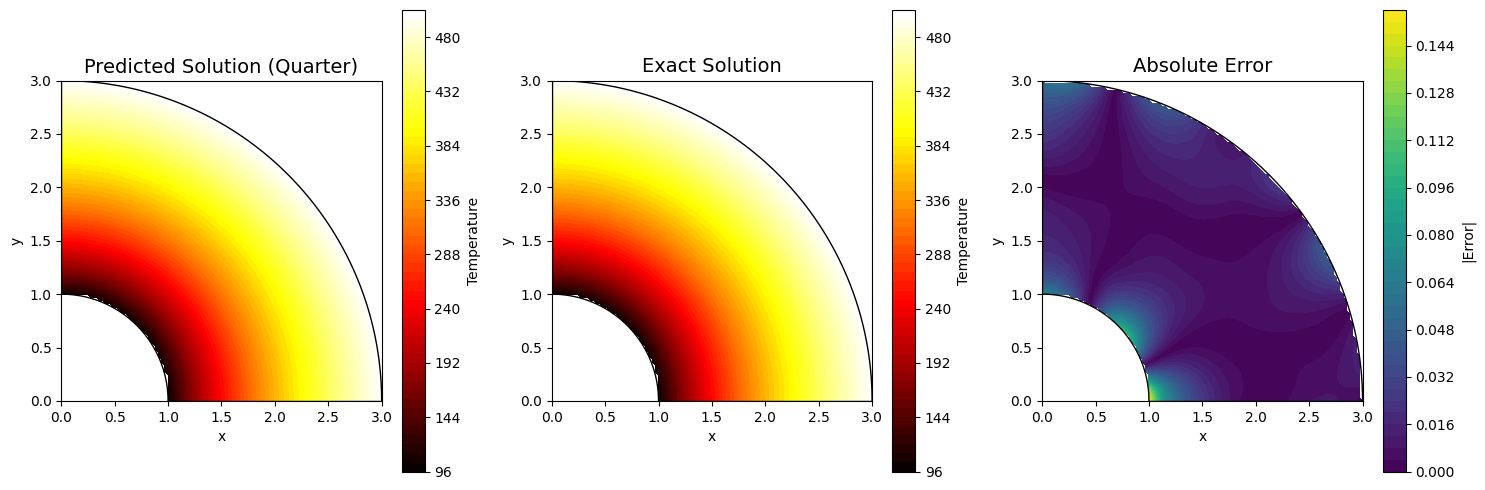

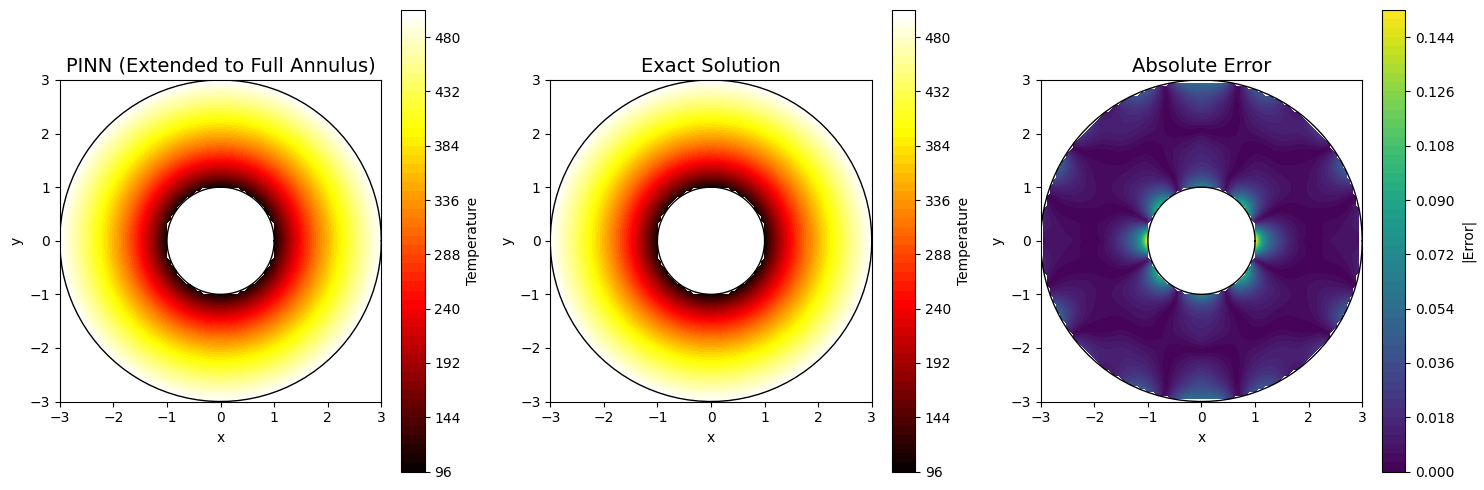

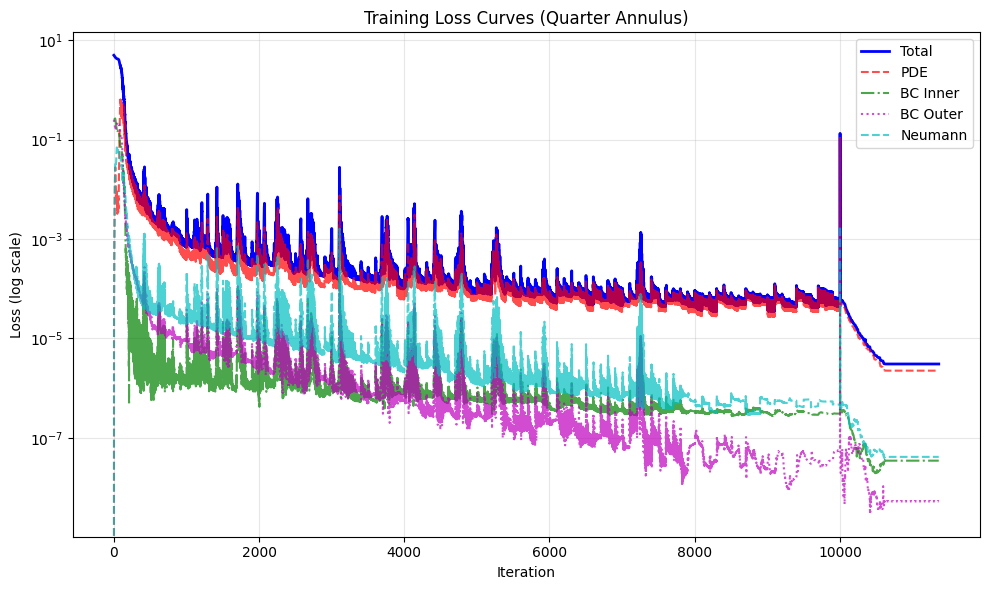

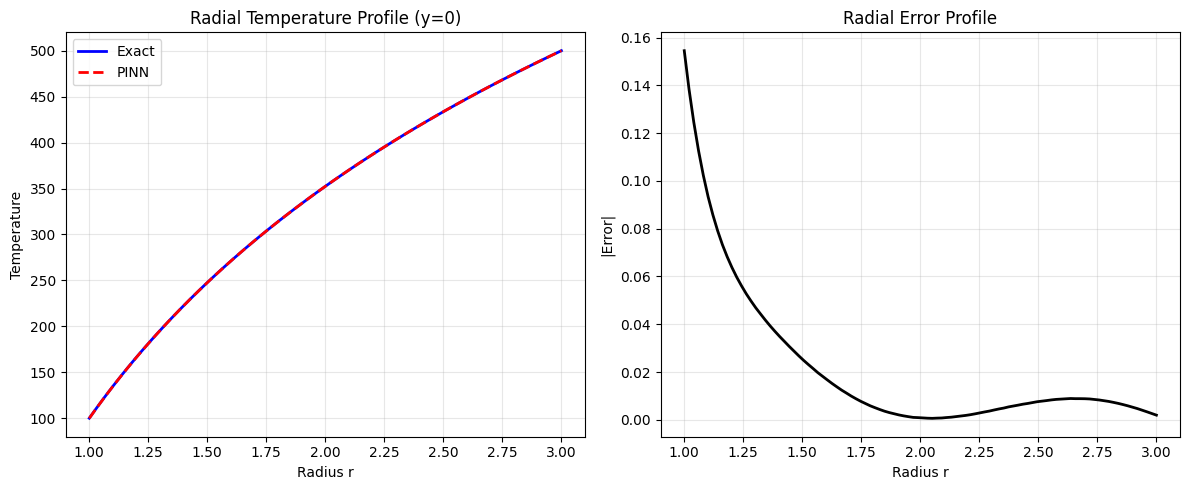

In [ ]:
def run_pinn(
    R1: float = 1.0,
    R2: float = 3.0,
    T_cold: float = 100.0,
    T_hot: float = 500.0,
    hidden_layers: int = 4,
    neurons_per_layer: int = 32,
    adam_iterations: int = 10000,
    lbfgs_iterations: int = 3000,
    lambda_pde: float = 1.0,
    lambda_bc: float = 10.0
) -> Tuple[PINN, dict, float, float]:
    """
    Run complete PINN training and visualization for quarter annulus.
    Interface matches full geometry code for easy comparison.
    """

    config = Config(
        R1=R1, R2=R2,
        T_cold=T_cold, T_hot=T_hot,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        adam_iterations=adam_iterations,
        lbfgs_iterations=lbfgs_iterations,
        lambda_pde=lambda_pde,
        lambda_bc=lambda_bc
    )

    print(config)

    model = PINN(config).to(config.device)
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}\n")

    trainer = Trainer(config, model)
    trainer.train()

    analytics = Analytics(config)
    abs_err, rel_err = analytics.compute_l2_error(model)

    print(f"\n{'='*60}")
    print(f"Error Metrics:")
    print(f"  Absolute L2 Error: {abs_err:.4e}")
    print(f"  Relative L2 Error: {rel_err:.4%}")
    print(f"  Training Time: {trainer.training_time:.2f} s")
    print(f"{'='*60}")

    visualizer = Visualizer(config)
    visualizer.plot_solution(model, analytics)
    visualizer.plot_full_annulus(model, analytics)
    visualizer.plot_loss_curves(trainer.history)
    visualizer.plot_radial_profile(model, analytics)

    return model, trainer.history, abs_err, rel_err


if __name__ == "__main__":
    model, history, abs_err, rel_err = run_pinn(
        R1=1.0,
        R2=3.0,
        T_cold=100.0,
        T_hot=500.0,
        hidden_layers=4,
        neurons_per_layer=32,
        adam_iterations=10000,
        lbfgs_iterations=3000,
        lambda_pde=1.0,
        lambda_bc=10.0
    )